# 多模型训练与对比

本 Notebook 仅读取已有评估文件与图表，不重新训练模型。

## 1. 读取结果文件

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

def find_project_root():
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'config.yaml').exists() and (p / 'outputs').exists():
            return p
    return cwd

project_root = find_project_root()
metrics_dir = project_root / 'outputs' / 'metrics'
fig_dir = project_root / 'outputs' / 'figures'

model_df = pd.read_csv(metrics_dir / 'model_comparison.csv')
threshold_df = pd.read_csv(metrics_dir / 'threshold_analysis.csv')
report_text = (metrics_dir / 'classification_reports.txt').read_text(encoding='utf-8')

print('项目根目录:', project_root)
print('模型结果行数:', len(model_df))

项目根目录: E:\TelecomCustomer_ChurnPrediction
模型结果行数: 4


## 2. 多模型结果表

In [2]:
display(model_df)
best = model_df.sort_values('roc_auc', ascending=False).iloc[0]
print('按 ROC-AUC 选择的最佳模型:', best['model'])
print('ROC-AUC:', round(float(best['roc_auc']), 4))
print('PR-AUC:', round(float(best['pr_auc']), 4))

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,xgboost,0.756565,0.527928,0.783422,0.630786,0.842995,0.655574
1,logistic_regression,0.740241,0.506920,0.783422,0.615546,0.841226,0.630617
2,lightgbm,0.755145,0.528713,0.713904,0.607509,0.833230,0.639841
3,random_forest,0.791341,0.631579,0.513369,0.566372,0.830643,0.628258


按 ROC-AUC 选择的最佳模型: xgboost
ROC-AUC: 0.843
PR-AUC: 0.6556


## 3. 模型指标对比图

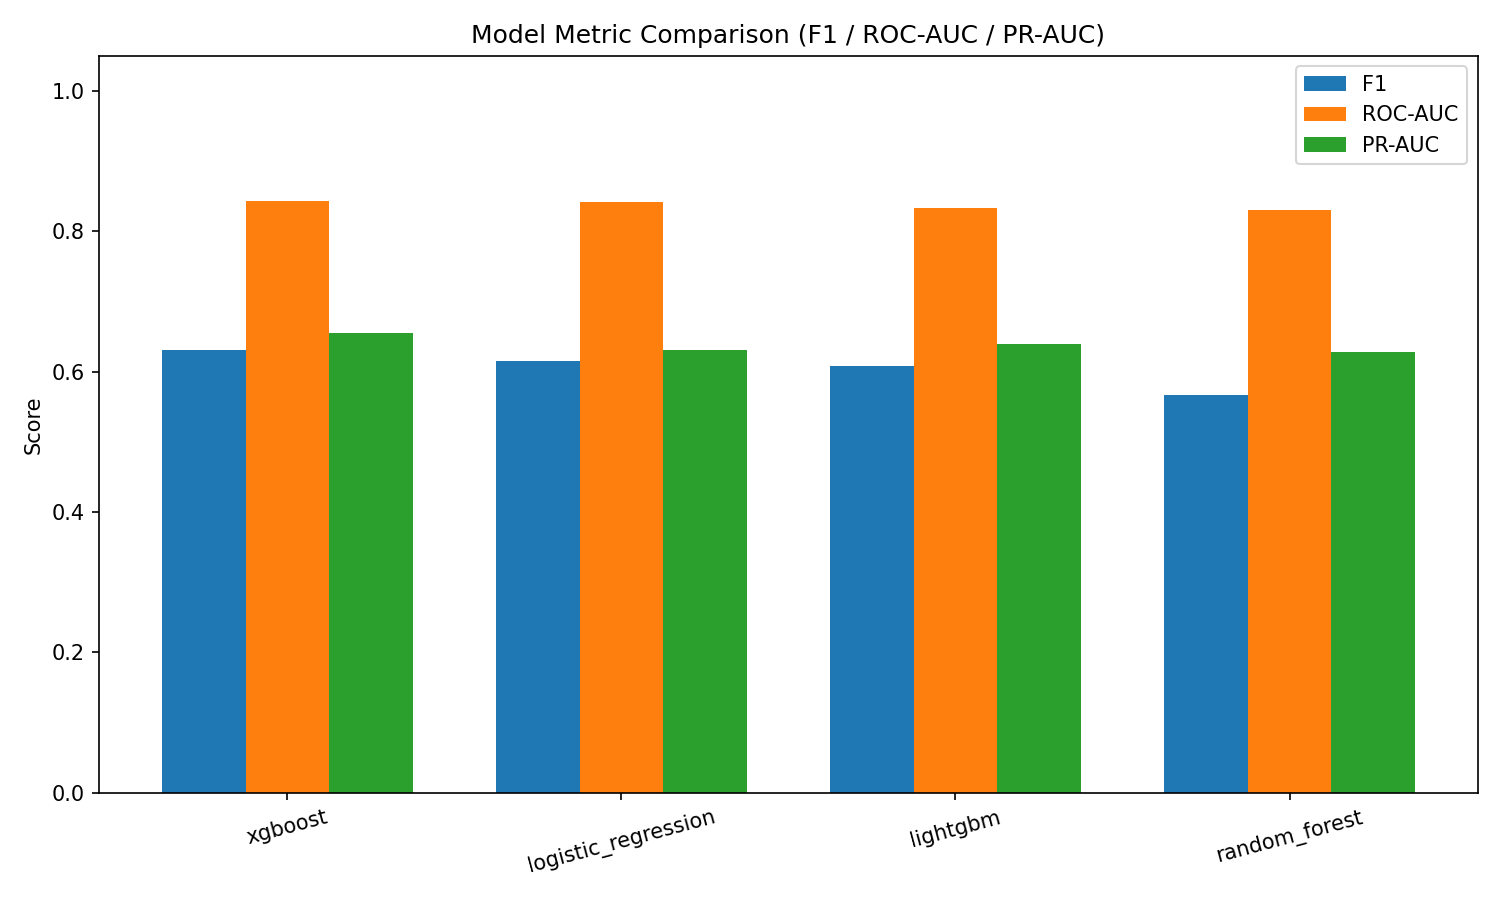

In [3]:
display(Image(filename=str(fig_dir / 'model_comparison.png')))

## 4. ROC 曲线图

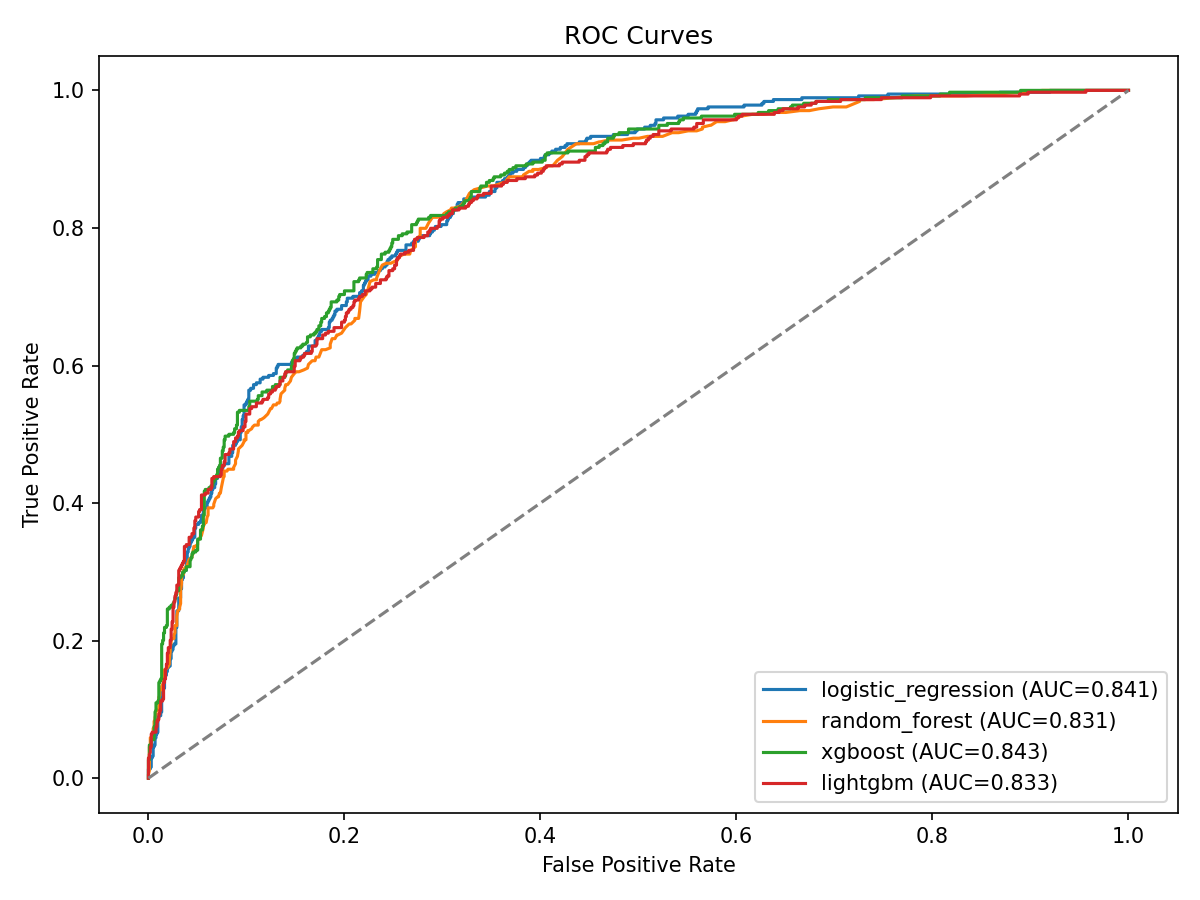

In [4]:
display(Image(filename=str(fig_dir / 'roc_curve.png')))

## 5. PR 曲线图

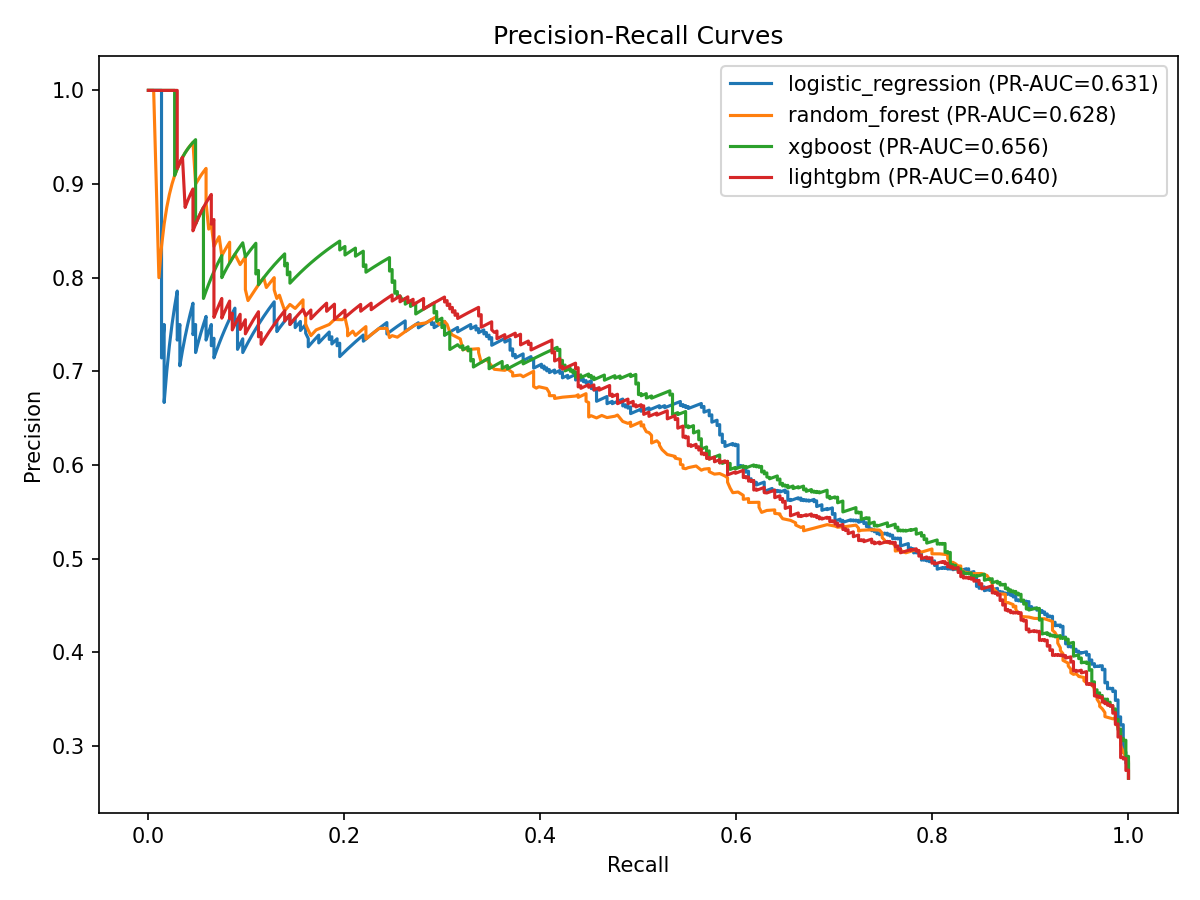

In [5]:
display(Image(filename=str(fig_dir / 'pr_curve.png')))

## 6. 最佳模型混淆矩阵

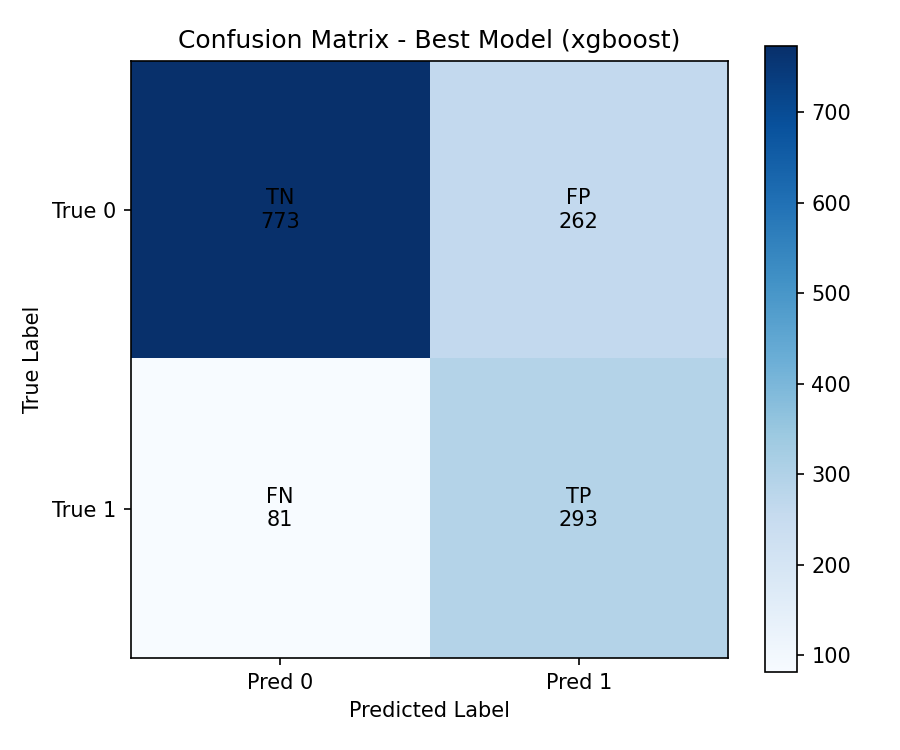

In [6]:
display(Image(filename=str(fig_dir / 'confusion_matrix_best_model.png')))

## 7. 阈值分析结果

,threshold,precision,recall,f1
0,0.3,0.455540,0.890374,0.602715
1,0.4,0.485179,0.831551,0.612808
2,0.5,0.527928,0.783422,0.630786
3,0.6,0.565502,0.692513,0.622596
4,0.7,0.638037,0.556150,0.594286


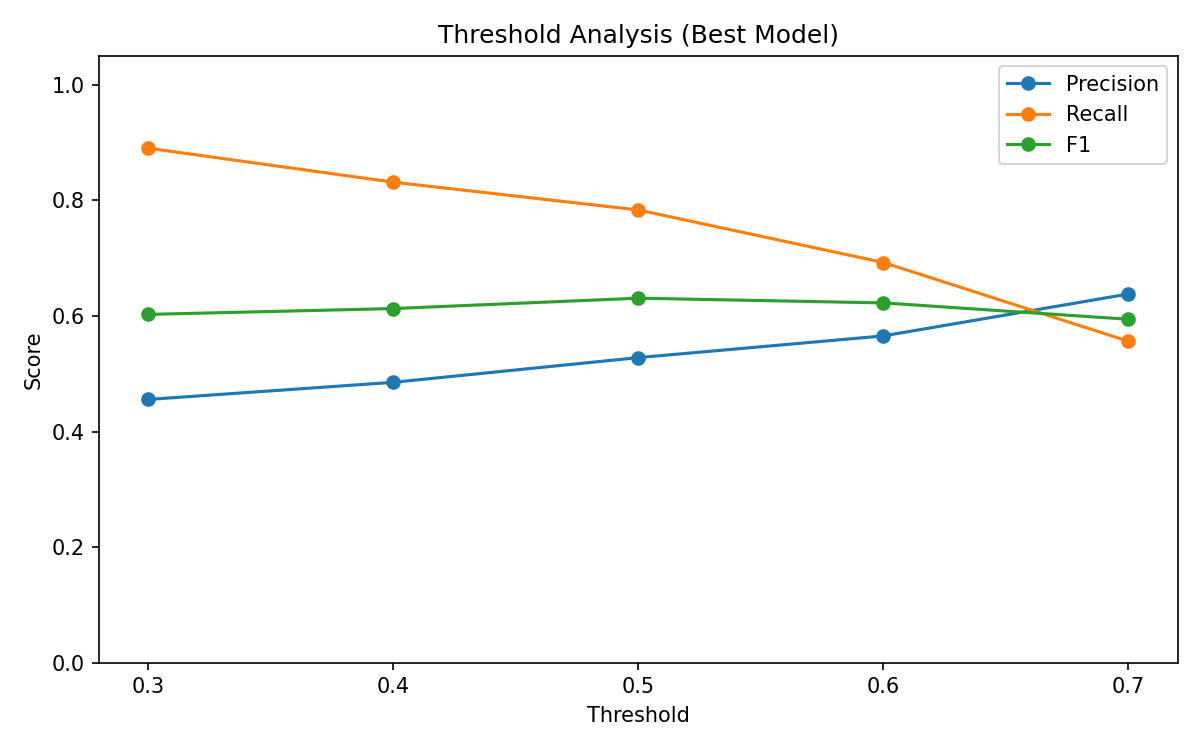

In [7]:
display(threshold_df)
display(Image(filename=str(fig_dir / 'threshold_analysis.png')))

## 8. 分类报告文本

In [8]:
print(report_text[:4000])

[logistic_regression]
              precision    recall  f1-score   support

           0     0.9025    0.7246    0.8039      1035
           1     0.5069    0.7834    0.6155       374

    accuracy                         0.7402      1409
   macro avg     0.7047    0.7540    0.7097      1409
weighted avg     0.7975    0.7402    0.7539      1409


[random_forest]
              precision    recall  f1-score   support

           0     0.8353    0.8918    0.8626      1035
           1     0.6316    0.5134    0.5664       374

    accuracy                         0.7913      1409
   macro avg     0.7334    0.7026    0.7145      1409
weighted avg     0.7812    0.7913    0.7840      1409


[xgboost]
              precision    recall  f1-score   support

           0     0.9052    0.7469    0.8184      1035
           1     0.5279    0.7834    0.6308       374

    accuracy                         0.7566      1409
   macro avg     0.7165    0.7651    0.7246      1409
weighted avg     0.8050 

## 9. 为什么选择 XGBoost
- 类别不平衡任务中，Accuracy 不能单独作为模型优劣判断标准。
- 流失场景更关注正类识别能力，因此要综合看 recall、roc_auc、pr_auc。
- XGBoost 在 roc_auc 与 pr_auc 上综合表现最佳，更适合高风险客户筛选。
- Random Forest 虽然 Accuracy 较高，但在流失客户识别的综合能力上不如 XGBoost。